# Add to the path

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

# Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


import torch
from torch import nn
from torch import optim
import time

import tltorch
from Utils.Reshape import reshape

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Synthetic Data

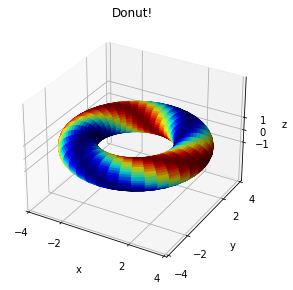

In [35]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import cm

# fig = plt.figure(num=1, clear=True)
# ax = fig.add_subplot(1, 1, 1, projection='3d')

# (theta, phi) = np.meshgrid(np.linspace(0, 2 * np.pi, 41),
#                            np.linspace(0, 2 * np.pi, 41))

# x = (3 + np.cos(phi)) * np.cos(theta)
# y = (3 + np.cos(phi)) * np.sin(theta)
# z = np.sin(phi)


# def fun(t, f): return (np.cos(f + 2 * t) + 1) / 2


# dplot = ax.plot_surface(x, y, z, facecolors=cm.jet(fun(theta, phi)))
# ax.set(xlabel='x', 
#        ylabel='y', 
#        zlabel='z',
#        xlim = [-4, 4],
#        ylim = [-4, 4],
#        zlim = [-4, 4],
#        xticks = [-4, -2, 2, 4],
#        yticks = [-4, -2, 2, 4],
#        zticks = [-1, 0, 1],
#        title='Donut!')

# fig.tight_layout()

In [39]:
z.shape

(41, 41)

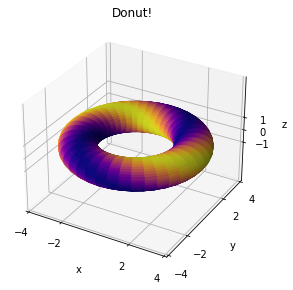

In [48]:
# fig = plt.figure(num=1, clear=True)
# ax = fig.add_subplot(1, 1, 1, projection='3d')

# dplot = ax.plot_surface(donut_tensor[:,:,0], donut_tensor[:,:,1], donut_tensor[:,:,2], facecolors=cm.get_cmap('plasma')(fun(theta, phi)))
# ax.set(xlabel='x', 
#        ylabel='y', 
#        zlabel='z',
#        xlim = [-4, 4],
#        ylim = [-4, 4],
#        zlim = [-4, 4],
#        xticks = [-4, -2, 2, 4],
#        yticks = [-4, -2, 2, 4],
#        zticks = [-1, 0, 1],
#        title='Donut!')

# fig.tight_layout()
# plt.show()

In [36]:
# import numpy as np

# # Define the dimensions of the donut surface
# rows, cols = x.shape

# # Create a 3D tensor to represent the donut surface
# donut_tensor = np.zeros((rows, cols, 3))

# # Assign the x, y, and z coordinates to the tensor
# donut_tensor[:, :, 0] = x
# donut_tensor[:, :, 1] = y
# donut_tensor[:, :, 2] = z

# # Print the shape of the 3D tensor
# print("Shape of the 3D tensor representing the donut surface:", donut_tensor.shape)


Shape of the 3D tensor representing the donut surface: (41, 41, 3)


In [50]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Create a 2D array representing the image
# size = 100
# x, y = np.meshgrid(np.linspace(-1, 1, size), np.linspace(-1, 1, size))

# # Create the plus sign
# plus_sign = np.zeros_like(x)
# plus_sign[(x >= -0.5) & (x <= 0.5)] = 1
# plus_sign[(y >= -0.5) & (y <= 0.5)] = 1

# # Create the image
# fig, ax = plt.subplots(figsize=(5, 5))
# ax.imshow(plus_sign, cmap='binary')
# ax.set_axis_off()
# plt.show()


In [49]:
# size = 100
# x, y = np.meshgrid(np.linspace(-1, 1, size), np.linspace(-1, 1, size))
# circle = x**2 + y**2 <= 0.5**2

# # Create the image
# fig, ax = plt.subplots(figsize=(5, 5))
# ax.imshow(circle, cmap='binary')
# ax.set_axis_off()
# plt.show()

IndexError: index 42 is out of bounds for axis 0 with size 41

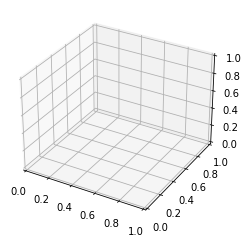

In [62]:
def generate_gaussian_tensor(n_samples, size):
    mean = 0
    variance = 5
    std_dev = torch.sqrt(torch.tensor(variance))
    tensor = np.random.normal(mean, std_dev, (n_samples, size, size))
    tensor = torch.from_numpy(tensor).float()

    (theta, phi) = np.meshgrid(np.linspace(0, 2 * np.pi, size),
                           np.linspace(0, 2 * np.pi, size))
    
    Weight = torch.zeros((size, size, 3))
    Weight[:,:,0] = torch.from_numpy((3 + np.cos(phi)) * np.cos(theta)).float()
    Weight[:,:,1] = torch.from_numpy((3 + np.cos(phi)) * np.sin(theta)).float()
    Weight[:,:,2] = torch.from_numpy(np.sin(phi)).float()

    output  = torch.einsum('abc, bco->ao', tensor, Weight)

    return tensor, output, Weight

n_samples = 100
size = 64

samples, y, W = generate_gaussian_tensor(n_samples, size)


fig = plt.figure(num=1, clear=True)
ax = fig.add_subplot(1, 1, 1, projection='3d')

def fun(t, f): return (np.cos(f + 2 * t) + 1) / 2
dplot = ax.plot_surface(W[:,:,0], W[:,:,1], W[:,:,2], facecolors=cm.get_cmap('plasma')(fun(theta, phi)))
ax.set(xlim = [-4, 4],
       ylim = [-4, 4],
       zlim = [-4, 4],
       xticks = [-4, -2, 2, 4],
       yticks = [-4, -2, 2, 4],
       zticks = [-1, 0, 1])

fig.tight_layout()
plt.show()


In [57]:
W.shape

torch.Size([10, 10, 3])

# Basic Linear Model

Epoch [1/5], Loss: 6466515.5
Epoch [2/5], Loss: 6384163.5
Epoch [3/5], Loss: 6302357.0
Epoch [4/5], Loss: 6221104.5
Epoch [5/5], Loss: 6140414.0
Done Training


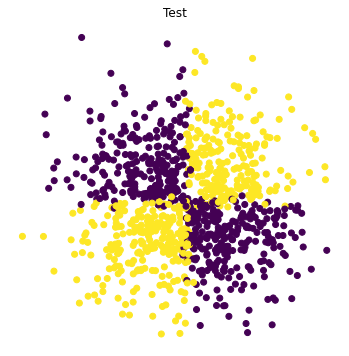

In [73]:
class simple_linear(nn.Module):
    def __init__(self):
        super(simple_linear, self).__init__()
        self.fc = nn.Linear(in_features= 64*64*64, out_features=2)
    def forward(self, x):
        x = x.reshape(-1,64*64*64)
        return self.fc(x)
    
model = simple_linear().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()

# Basic TRL Model

Epoch [1/5], Loss: 7332061.0
Epoch [2/5], Loss: 7011598.5
Epoch [3/5], Loss: 6706835.0
Epoch [4/5], Loss: 6417262.0
Epoch [5/5], Loss: 6142228.5
Done Training


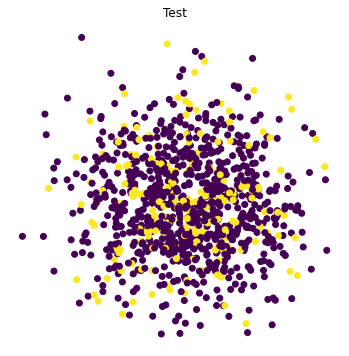

In [75]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(64,64,64), rank=(64,64,64,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()

# Basic Attached Model

Epoch [1/5], Loss: 6549921.0
Epoch [2/5], Loss: 6521711.5
Epoch [3/5], Loss: 6494307.0
Epoch [4/5], Loss: 6467566.0
Epoch [5/5], Loss: 6441310.5
Done Training


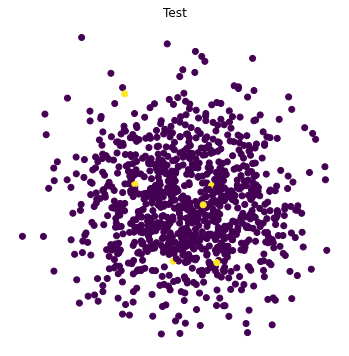

In [78]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[2,2,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(2,2,2,32,32,32), rank=(2,2,2,32,32,32,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()

# Basic Compressed Model

Epoch [1/5], Loss: 6938117.0
Epoch [2/5], Loss: 6864162.5
Epoch [3/5], Loss: 6792626.5
Epoch [4/5], Loss: 6723414.0
Epoch [5/5], Loss: 6656418.0
Done Training


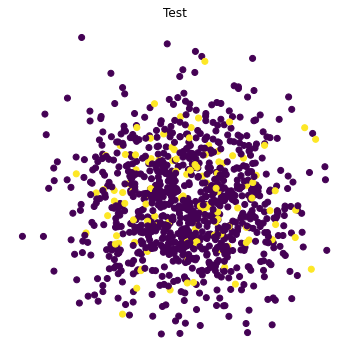

In [79]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[2,2,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(2,2,2,32,32,32), rank=(2,2,2,32,32,32,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()